In [1]:
import os
os.chdir('../..')

In [34]:
import selfies as sf
from scipy.spatial.distance import cosine, euclidean
from utils.load_datasets import QM9Loader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
qm9 = QM9Loader()

# Morgan Fingerprints

In [4]:
df_morgan_fingerprint = qm9.get_morgan_fingerprints(radius=3, fp_size=2048)

2026-02-09 16:52:20.266 | WARNING  | utils.load_datasets:get_morgan_fingerprints:320 - DataFrame is empty. Loading data first...
2026-02-09 16:52:20.268 | INFO     | utils.load_datasets:load_data:108 - Found existing QM9 dataset at data/QM9/dataset_cleaned.csv. Loading with Polars...
2026-02-09 16:52:20.320 | INFO     | utils.load_datasets:load_data:121 - Found existing Grassmann Stress Test at data/QM9/stress_test_perturbations.xyz. Skipping generation.
2026-02-09 16:52:20.324 | INFO     | utils.load_datasets:get_morgan_fingerprints:323 - Computing Morgan Fingerprints (Radius=3, Size=2048)...


In [5]:
df_morgan = df_morgan_fingerprint['morgan_fingerprint']
df_morgan_list = list(df_morgan)

validating that it has done it correct. 

In [6]:
for _, ls in enumerate(df_morgan_list[0:4]):
    for i, val in enumerate(ls):
        if val == 1:
            print(i)

1264
930
790
915
1119


# Validate One-Hot and Transformer embeddings

In [7]:
df = qm9.get_selfies_embeddings()

2026-02-09 16:52:23.414 | INFO     | utils.load_datasets:get_selfies_embeddings:434 - Generating SELFIES strings...
2026-02-09 16:52:23.548 | INFO     | utils.load_datasets:get_selfies_embeddings:451 - Computing One-Hot Encodings...
2026-02-09 16:52:23.567 | INFO     | utils.load_datasets:get_selfies_embeddings:454 - Computing Transformer Embeddings...
2026-02-09 16:52:23.568 | INFO     | utils.load_datasets:_generate_selfies_transformer:383 - Loading Transformer model: seyonec/ChemBERTa-zinc-base-v1...
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1964.41it/s, Materializing param=pooler.dense.weight]                             
RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.b

In [12]:
onehot_matrix = df["selfies_onehot"][0]

print(f"Number of tokens (Sequence Length): {len(onehot_matrix)}")
print(f"Vocabulary Size (Tokens in alphabet): {len(onehot_matrix[0])}")

is_valid = all(sum(row) == 1 for row in onehot_matrix)
print(f"Is strictly one-hot: {is_valid}")

smiles = df["canonical_smiles"][0] # e.g., "C"
selfie_str = sf.encoder(smiles)    # e.g., "[C]"
print(f"SELFIES: {selfie_str}")
print(f"Tokens: {list(sf.split_selfies(selfie_str))}") # Should match matrix row count (plus padding)

Number of tokens (Sequence Length): 15
Vocabulary Size (Tokens in alphabet): 39
Is strictly one-hot: True
SELFIES: [C]
Tokens: ['[C]']


In [16]:
transformer_vec = df["selfies_transformer"][0]
print(f"Embedding dimension: {len(transformer_vec)}") # Should be 768

vec_0 = df["selfies_transformer"][0]
vec_1 = df["selfies_transformer"][1]

# Check if they are actually different
print(f"Are vectors identical? {vec_0 == vec_1}")

# Similarity = 1 - distance
similarity = 1 - cosine(df["selfies_transformer"][0], df["selfies_transformer"][1])
print(f"Similarity between first two molecules: {similarity}")

Embedding dimension: 768
Are vectors identical? shape: (768,)
Series: '' [bool]
[
	false
	false
	false
	false
	false
	…
	false
	false
	false
	false
	false
]
Similarity between first two molecules: 0.7993101949537702


In [17]:
import polars as pl

# Check for nulls
null_counts = df.select([
    pl.col("selfies_onehot").is_null().sum().alias("onehot_nulls"),
    pl.col("selfies_transformer").is_null().sum().alias("transformer_nulls")
])
print(null_counts)

# Check if any transformer vectors are all zeros (indicating a failure in the model pass)
all_zeros = all(v == 0 for v in df["selfies_transformer"][0])
print(f"Is first transformer vector empty/zeros? {all_zeros}")

shape: (1, 2)
┌──────────────┬───────────────────┐
│ onehot_nulls ┆ transformer_nulls │
│ ---          ┆ ---               │
│ u32          ┆ u32               │
╞══════════════╪═══════════════════╡
│ 0            ┆ 0                 │
└──────────────┴───────────────────┘
Is first transformer vector empty/zeros? False


# Distance metrics
## Morgan (Jaccard)

In [39]:
def plot_distance_heatmaps(dist_morgan, dist_selfies, subset_size=100):
    """
    Plots heatmaps for Morgan and SELFIES distance matrices.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # 1. Morgan (Jaccard) Heatmap
    sns.heatmap(
        dist_morgan[:subset_size, :subset_size], 
        ax=axes[0], 
        cmap="magma", 
        cbar_kws={'label': 'Jaccard Distance'}
    )
    axes[0].set_title(f"Morgan Fingerprints (First {subset_size})")
    axes[0].set_xlabel("Molecule Index")
    axes[0].set_ylabel("Molecule Index")

    # 2. SELFIES (Euclidean) Heatmap
    sns.heatmap(
        dist_selfies[:subset_size, :subset_size], 
        ax=axes[1], 
        cmap="magma", 
        cbar_kws={'label': 'Euclidean Distance'}
    )
    axes[1].set_title(f"SELFIES Transformer (First {subset_size})")
    axes[1].set_xlabel("Molecule Index")
    axes[1].set_ylabel("Molecule Index")

    plt.tight_layout()
    #plt.savefig("distance_comparison_heatmap.png")
    plt.show()

In [20]:
distance_morgan = qm9.get_dist_matrix(distance_type='morgan')
distance_morgan

2026-02-09 16:56:50.146 | INFO     | utils.load_datasets:get_dist_matrix:509 - Loading existing morgan distance matrix from data/QM9/dist_matrix_morgan.npy...


array([[0.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 0.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 1.        , 0.        , ..., 1.        , 1.        ,
        1.        ],
       ...,
       [1.        , 1.        , 1.        , ..., 0.        , 0.62962963,
        0.68965517],
       [1.        , 1.        , 1.        , ..., 0.62962963, 0.        ,
        0.74193548],
       [1.        , 1.        , 1.        , ..., 0.68965517, 0.74193548,
        0.        ]], shape=(2000, 2000))

In [21]:
# A. Check if the diagonal is all zeros (Distance to self must be 0)
diagonal_sum = np.trace(distance_morgan)
print(f"Diagonal sum (should be 0): {diagonal_sum}")

# B. Check for symmetry (Distance A->B must equal B->A)
is_symmetric = np.allclose(distance_morgan, distance_morgan.T)
print(f"Is symmetric: {is_symmetric}")

# C. Check range (Jaccard/Tanimoto distance must be between 0 and 1)
print(f"Min value: {distance_morgan.min()}, Max value: {distance_morgan.max()}")

Diagonal sum (should be 0): 0.0
Is symmetric: True
Min value: 0.0, Max value: 1.0


In [27]:
from rdkit import DataStructs, Chem
from rdkit.Chem import AllChem

# 1. Get fingerprints directly from the source SMILES for Row 0 and Row 1
smiles_0 = qm9.df["canonical_smiles"][0]
smiles_1 = qm9.df["canonical_smiles"][1]

mol0 = Chem.MolFromSmiles(smiles_0)
mol1 = Chem.MolFromSmiles(smiles_1)

# Generate Morgan Fingerprints (BitVectors)
radius=3
fp_size=2048
morgan_gen = AllChem.GetMorganGenerator(radius=radius, fpSize=fp_size)

fp0 = morgan_gen.GetFingerprint(mol0)
fp1 = morgan_gen.GetFingerprint(mol1)

# 2. Calculate Tanimoto Distance (1 - Similarity)
rdkit_sim = DataStructs.TanimotoSimilarity(fp0, fp1)
rdkit_dist = 1 - rdkit_sim

# 3. Compare with your matrix value
matrix_dist = distance_morgan[0, 1]

print(f"Molecules: {smiles_0} vs {smiles_1}")
print(f"RDKit Distance: {rdkit_dist}")
print(f"Matrix Distance: {matrix_dist}")
print(f"Match: {np.isclose(rdkit_dist, matrix_dist)}")

Molecules: C vs N
RDKit Distance: 1.0
Matrix Distance: 1.0
Match: True


## Selfies (Euclidian)

In [28]:
distance_selfies = qm9.get_dist_matrix(distance_type='selfies')
distance_selfies

2026-02-09 17:04:57.746 | INFO     | utils.load_datasets:get_dist_matrix:513 - Generating selfies distance matrix...
2026-02-09 17:04:57.829 | INFO     | utils.load_datasets:get_dist_matrix:523 - Computing euclidean distances for shape (2000, 768)...
2026-02-09 17:04:58.184 | SUCCESS  | utils.load_datasets:get_dist_matrix:537 - Saved dist_matrix_selfies.npy (Shape: (2000, 2000))


array([[ 0.        , 16.082492  , 15.68325265, ..., 24.38528419,
        24.76400249, 24.55700913],
       [16.082492  ,  0.        ,  8.59852143, ..., 21.5731069 ,
        21.74129478, 21.27639593],
       [15.68325265,  8.59852143,  0.        , ..., 22.36643667,
        22.39911028, 22.40030296],
       ...,
       [24.38528419, 21.5731069 , 22.36643667, ...,  0.        ,
         2.69483023,  3.04408807],
       [24.76400249, 21.74129478, 22.39911028, ...,  2.69483023,
         0.        ,  3.07875335],
       [24.55700913, 21.27639593, 22.40030296, ...,  3.04408807,
         3.07875335,  0.        ]], shape=(2000, 2000))

In [30]:
# A. Check if the diagonal is all zeros (Distance to self must be 0)
diagonal_sum = np.trace(distance_selfies)
print(f"Diagonal sum (should be 0): {diagonal_sum}")

# B. Check for symmetry (Distance A -> B must equal B -> A)
is_symmetric = np.allclose(distance_selfies, distance_selfies.T, atol=1e-5)
print(f"Is symmetric: {is_symmetric}")

# C. Check for non-negativity (Euclidean distance cannot be negative)
is_non_negative = np.all(distance_selfies >= 0)
print(f"Are all values >= 0: {is_non_negative}")

Diagonal sum (should be 0): 0.0
Is symmetric: True
Are all values >= 0: True


In [32]:
# 1. Extract the transformer embeddings for row 0 and row 1
vec_0 = np.array(qm9.df["selfies_transformer"][0])
vec_1 = np.array(qm9.df["selfies_transformer"][1])

# 2. Manually calculate Euclidean distance: sqrt(sum((vec_0 - vec_1)^2))
manual_dist = euclidean(vec_0, vec_1)

# 3. Compare with your matrix value
matrix_dist = distance_selfies[0, 1]

print(f"Manual Calculation: {manual_dist}")
print(f"Matrix Value: {matrix_dist}")
print(f"Match: {np.isclose(manual_dist, matrix_dist, atol=1e-5)}")

Manual Calculation: 16.082491997828523
Matrix Value: 16.082491997828516
Match: True


In [33]:
# Methane (qm9_0) vs Ammonia (qm9_1) -> Both small, simple
dist_small_small = distance_selfies[0, 1]

# Methane (qm9_0) vs a larger molecule later in the dataset
dist_small_large = distance_selfies[0, 500] 

print(f"Distance (Methane to Ammonia): {dist_small_small}")
print(f"Distance (Methane to Molecule 500): {dist_small_large}")

# Validation: Usually, dist_small_small should be smaller than dist_small_large
# as the transformer captures the 'simplicity' or 'size' in its latent space.

Distance (Methane to Ammonia): 16.082491997828516
Distance (Methane to Molecule 500): 17.75199026333404


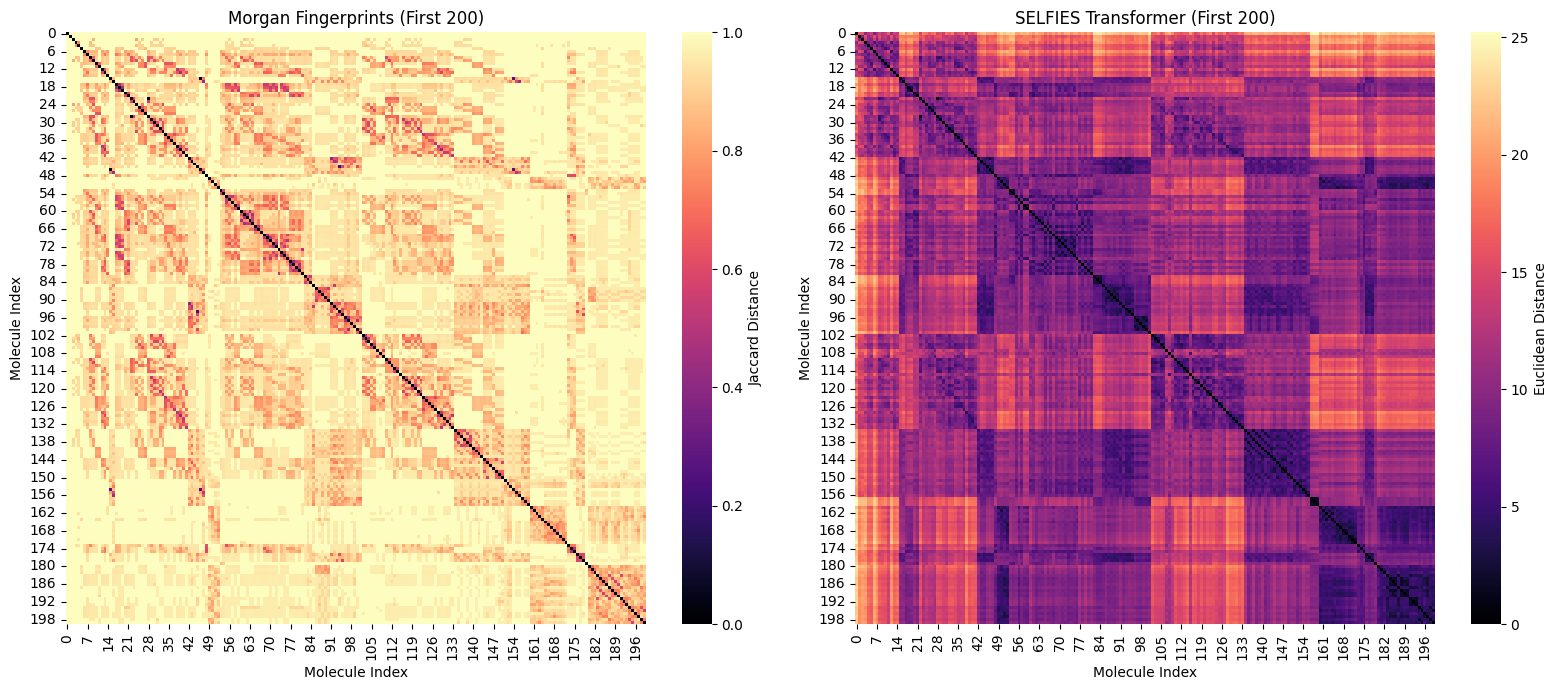

In [40]:
plot_distance_heatmaps(distance_morgan, distance_selfies, subset_size=200)